In [2]:
import pandas as pd
import numpy as np


In [ ]:


data = pd.read_csv("../data/GSE115469_Data.csv", index_col=0)

X = data.to_numpy(dtype=np.float32)
gene_names = data.index.to_numpy()
cell_names = data.columns.to_numpy()

del data  

print(X.shape)

In [2]:
X = X.T
print(X.shape)

(8444, 20007)


In [3]:
np.save("X_raw.npy", X)
np.save("gene_names.npy", gene_names)
np.save("cell_names.npy", cell_names)

In [6]:
X = np.load("X_raw.npy")
gene_names = np.load("gene_names.npy", allow_pickle=True)
cell_names = np.load("cell_names.npy", allow_pickle=True)

In [7]:
X[:5]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.31475955, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [8]:
variances = np.var(X, axis=0)
k = 3000
top_genes = np.argsort(variances)[-k:]

X = X[:, top_genes]
gene_names = gene_names[top_genes]

print(X.shape)


(8444, 3000)


In [9]:
from sklearn.preprocessing import StandardScaler   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
del X

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

print(X_pca.shape)

(8444, 50)


In [11]:
pca.explained_variance_ratio_.sum()

0.25720343

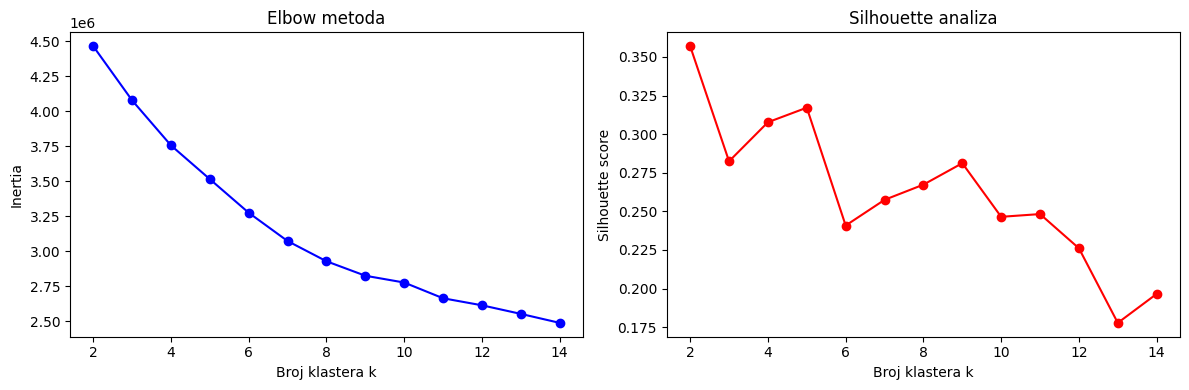

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel("Broj klastera k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow metoda")

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel("Broj klastera k")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette analiza")

plt.tight_layout()
plt.show()

In [13]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

np.save("cluster_labels.npy", cluster_labels)

2026-02-22 19:49:17.280594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 19:49:17.392052: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 19:49:17.422912: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-22 19:49:17.603805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 19:49:20.435939: W tensorflow/compiler/tf2

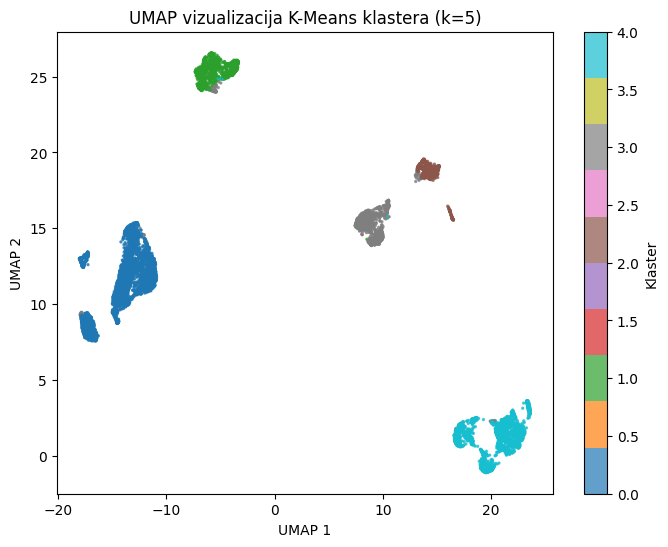

In [14]:

import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], 
                      c=cluster_labels, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('UMAP vizualizacija K-Means klastera (k=5)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

np.save("X_umap.npy", X_umap)